# Desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs (o utilizando un dataset propio).
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### Descarga y preprocesamiento del corpus

Utilizamos el texto completo de Moby Dick de Herman Melville, obtenido desde Project Gutenberg.

In [40]:
import urllib.request

dataset_url = "https://www.gutenberg.org/cache/epub/2701/pg2701.txt"

response = urllib.request.urlopen(dataset_url)
raw_text = response.read().decode("utf-8")

In [41]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# Regex to match Roman numerals (ii, iii, iv, vi, vii, etc.)
roman_re = re.compile(r'^(?:m{0,3})(?:cm|cd|d?c{0,3})(?:xc|xl|l?x{0,3})(?:ix|iv|v?i{0,3})$')

def is_roman_numeral(word):
    return bool(roman_re.match(word)) and len(word) > 0

# Split into lines and tokenize each line as a document
lines = [line.strip() for line in raw_text.split("\n") if line.strip()]

# Remove header and footer of Project Gutenberg
start_marker = "START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "END OF THE PROJECT GUTENBERG EBOOK"
start_line = [start_marker in line for line in lines].index(True)
end_line = [end_marker in line for line in lines].index(True)
lines = lines[start_line + 1 : end_line]

# Remove:
#   - single letter words
#   - punctuation
#   - numbers (including Roman numerals)
#   - stopwords
# And make them lowercase
cleaned_lines = []
for line in lines:
    words = re.findall(r'\b[a-zA-Z]+\b', line)
    cleaned_line = ' '.join(
        word.lower() for word in words
        if len(word) > 1
        and word.lower() not in stop_words
        and not is_roman_numeral(word.lower())
    )
    cleaned_lines.append(cleaned_line)

In [42]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
for line in cleaned_lines:
    tokens = text_to_word_sequence(line)
    if len(tokens) >= 3:  # only lines with at least 3 words
        sentence_tokens.append(tokens)

print(f"Numero de documentos (cleaned lines): {len(sentence_tokens)}")
print(f"Ejemplo: {sentence_tokens[150]}")

Numero de documentos (cleaned lines): 17857
Ejemplo: ['described', 'noble', 'prophet', 'moses', 'life', 'patient', 'job']


### Crear los vectores (Word2Vec)

Entrenamos un modelo de Word2Vec con arquitectura Skip-gram sobre el corpus de Moby Dick.

In [43]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

class LossCallback(CallbackAny2Vec):
    """Callback for printing the loss after each epoch."""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print(f"Loss after epoch {self.epoch}: {loss:.1f}")
        else:
            print(f"Loss after epoch {self.epoch}: {loss - self.loss_previous_step:.1f}")
        self.epoch += 1
        self.loss_previous_step = loss

w2v_model = Word2Vec(
    min_count=10,
    window=5,
    vector_size=50,
    negative=15,
    workers=1,
    sg=1  # Skip-gram
)

w2v_model.build_vocab(sentence_tokens)
print(f"Palabras en el vocabulario: {len(w2v_model.wv.index_to_key)}")
print(f"Documentos en el corpus: {w2v_model.corpus_count}")

w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=50,
    callbacks=[LossCallback()],
    compute_loss=True
)

Palabras en el vocabulario: 2015
Documentos en el corpus: 17857
Loss after epoch 0: 999616.2
Loss after epoch 1: 688039.4
Loss after epoch 2: 632946.9
Loss after epoch 3: 559262.5
Loss after epoch 4: 555818.8
Loss after epoch 5: 551429.8
Loss after epoch 6: 520291.0
Loss after epoch 7: 498268.5
Loss after epoch 8: 492689.0
Loss after epoch 9: 487417.0
Loss after epoch 10: 483721.0
Loss after epoch 11: 482051.5
Loss after epoch 12: 478107.5
Loss after epoch 13: 479018.5
Loss after epoch 14: 474623.0
Loss after epoch 15: 442510.5
Loss after epoch 16: 442153.0
Loss after epoch 17: 438954.0
Loss after epoch 18: 432088.0
Loss after epoch 19: 431976.0
Loss after epoch 20: 432229.0
Loss after epoch 21: 430678.0
Loss after epoch 22: 429760.0
Loss after epoch 23: 429012.0
Loss after epoch 24: 427027.0
Loss after epoch 25: 425482.0
Loss after epoch 26: 424927.0
Loss after epoch 27: 424463.0
Loss after epoch 28: 423612.0
Loss after epoch 29: 421137.0
Loss after epoch 30: 421256.0
Loss after epoch

(3455836, 5443300)

### Exploración de términos similares y disímiles

Elegimos términos relacionados a la temática de Moby Dick y exploramos las relaciones semánticas que el modelo aprendió.

In [44]:
# Similar words to "whale"
print("Palabras similares a 'whale'\n" + "="*30)
for word, score in w2v_model.wv.most_similar(positive=["whale"], topn=10):
    print(f"  {word:20s} {score:.4f}")

Palabras similares a 'whale'
  sperm                0.7364
  greenland            0.6627
  baleen               0.6627
  whales               0.6453
  instance             0.6309
  hump                 0.6261
  feeding              0.6251
  observe              0.6043
  used                 0.6038
  previously           0.5944


In [45]:
# Similar words to "sea"
print("Palabras similares a 'sea'\n" + "="*30)
for word, score in w2v_model.wv.most_similar(positive=["sea"], topn=10):
    print(f"  {word:20s} {score:.4f}")

Palabras similares a 'sea'
  salt                 0.6657
  caused               0.6399
  ships                0.6331
  rolling              0.6169
  fowl                 0.6015
  great                0.5746
  tossed               0.5746
  quick                0.5719
  rolls                0.5676
  gently               0.5664


In [46]:
# Similar words to "captain"
print("Palabras similares a 'captain'\n" + "="*30)
for word, score in w2v_model.wv.most_similar(positive=["captain"], topn=10):
    print(f"  {word:20s} {score:.4f}")

Palabras similares a 'captain'
  ahab                 0.6501
  peleg                0.6444
  straightway          0.6407
  entitled             0.6029
  commanded            0.5975
  service              0.5972
  bildad               0.5955
  said                 0.5852
  guernsey             0.5640
  desired              0.5630


In [47]:
# Less similar words to "life"
print("Palabras menos similares a 'life'\n" + "="*30)
for word, score in reversed(w2v_model.wv.most_similar(negative=["life"], topn=10)):
    print(f"  {word:20s} {score:.4f}")

Palabras menos similares a 'life'
  daggoo               0.0337
  post                 0.0344
  heaving              0.0461
  king                 0.0506
  hat                  0.0563
  prodigious           0.0596
  anchor               0.0598
  venerable            0.0654
  shipped              0.0714
  else                 0.1208


In [48]:
# Less similar words to "death"
print("Palabras menos similares a 'death'\n" + "="*30)
for word, score in reversed(w2v_model.wv.most_similar(negative=["death"], topn=10)):
    print(f"  {word:20s} {score:.4f}")

Palabras menos similares a 'death'
  mainmast             0.0402
  seated               0.0450
  duty                 0.0468
  substance            0.0663
  eight                0.0666
  either               0.0666
  weight               0.0716
  thrown               0.0814
  subject              0.1157
  binnacle             0.1654


### Interpretación de los términos similares

- **whale** (score máx. 0.74): El modelo captura la semántica relacionada a la cetología. Palabras como *sperm* (*sperm whale*), *greenland* y *baleen* refieren a cachalote y tipos de ballenas, *whales* es la forma plural, y *hump* y *feeding* describen características físicas y comportamiento de ballenas. Se observa algo de ruido con algunas palabras como *instance*, *observe* y *previously*.

- **sea** (score máx. 0.67): Las palabras asociadas reflejan el entorno marino y de navegación. *salt* claramente se relaciona al agua de mar, *ships* son barcos, *fowl* son aves marinas, y *tossed*, *rolls*, *gently* podrían relacionarse a movimientos del mar.

- **captain** (score máx. 0.65): El modelo asocia correctamente la palabra con personajes que ejercen esa labor en la novela. *ahab* es el capitán protagonista, y *peleg* y *bildad* son capitanes copropietarios del Pequod. *commanded* y *service* se relacionan directamente con el rol, y *straightway* y *said* son palabras relacionadas con las órdenes y diálogos de los capitanes.

- **Palabras menos similares a "life"**: El modelo aleja *life* de términos como *daggoo* (arponero), *post*, *heaving*, *anchor* que son palabras relacionadas al trabajo en el barco. Se observan algunas palabras con poco sentido como *king*, *hat* y *shipped*.

- **Palabras menos similares a "death"**: Se aleja de términos náuticos como *mainmast*, *seated*, *duty*. Parece no captar del todo bien los términos disímiles a *death* (como podrían ser *life* y otras palabras de seres vivos).

### Reducción de dimensionalidad y visualización

Reducimos los embeddings a 2D usando t-SNE para poder visualizarlos. Seleccionamos las `MAX_WORDS` palabras más frecuentes del vocabulario.

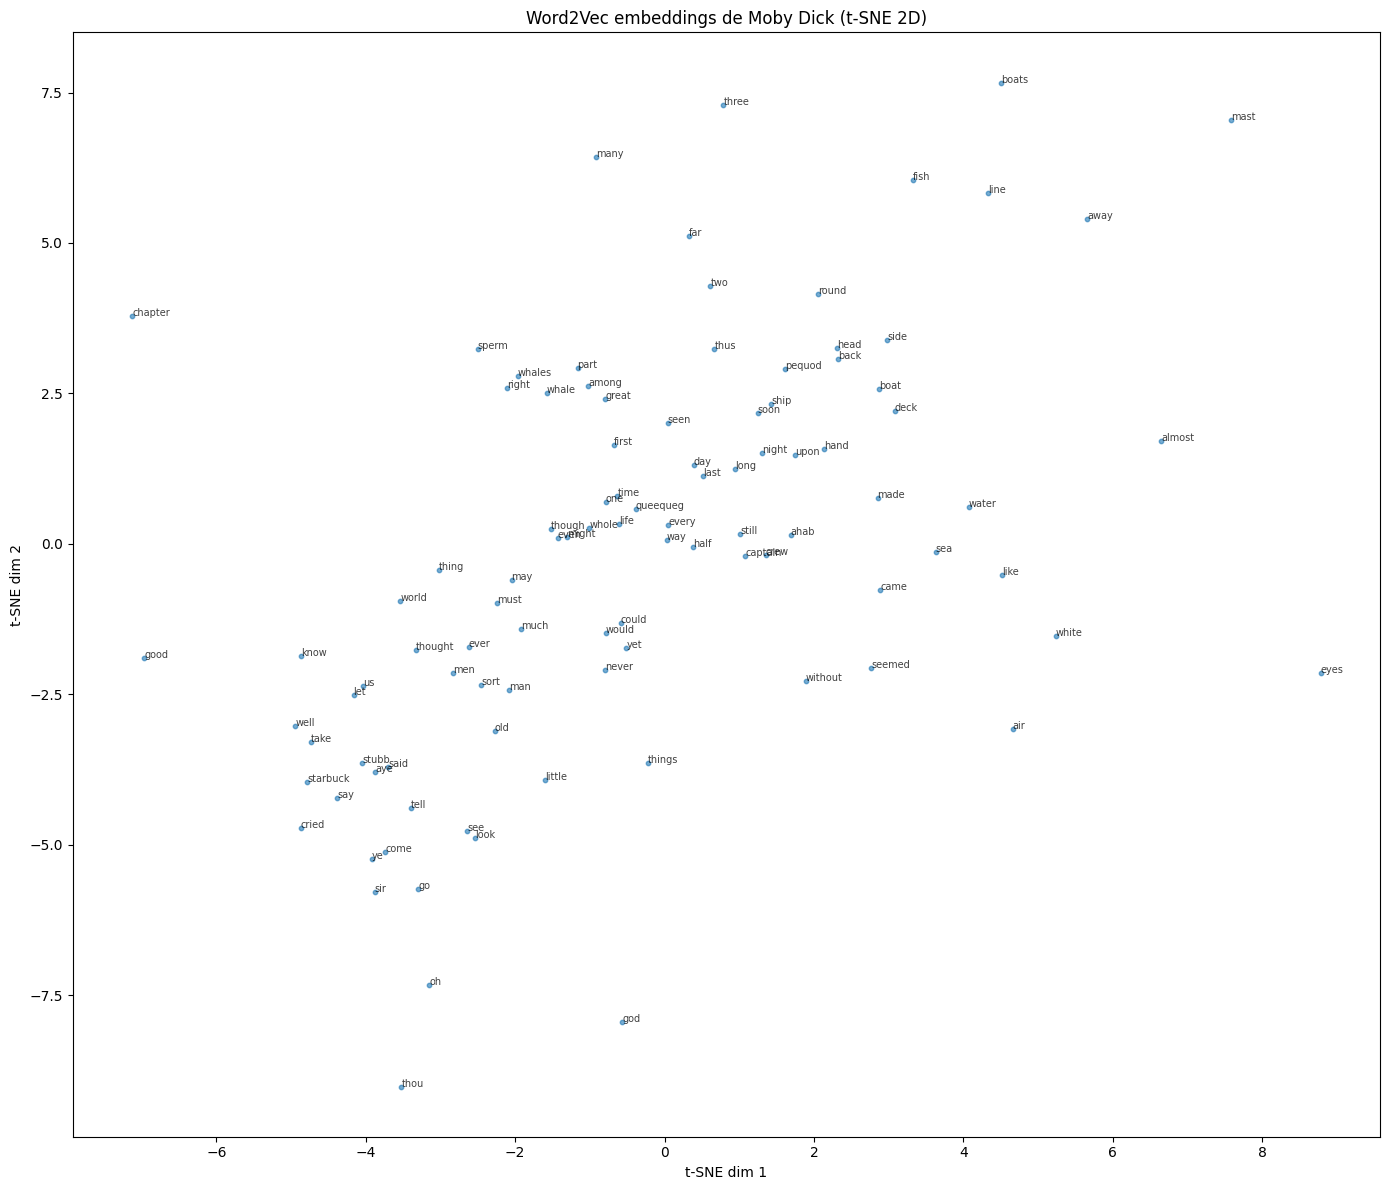

In [49]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)
    return vectors_2d, labels

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 100

plt.figure(figsize=(14, 12))
plt.scatter(vecs[:MAX_WORDS, 0], vecs[:MAX_WORDS, 1], s=10, alpha=0.6)
for i in range(MAX_WORDS):
    plt.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=7, alpha=0.75)
plt.title("Word2Vec embeddings de Moby Dick (t-SNE 2D)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

### Análisis de agrupaciones (clusters) de palabras

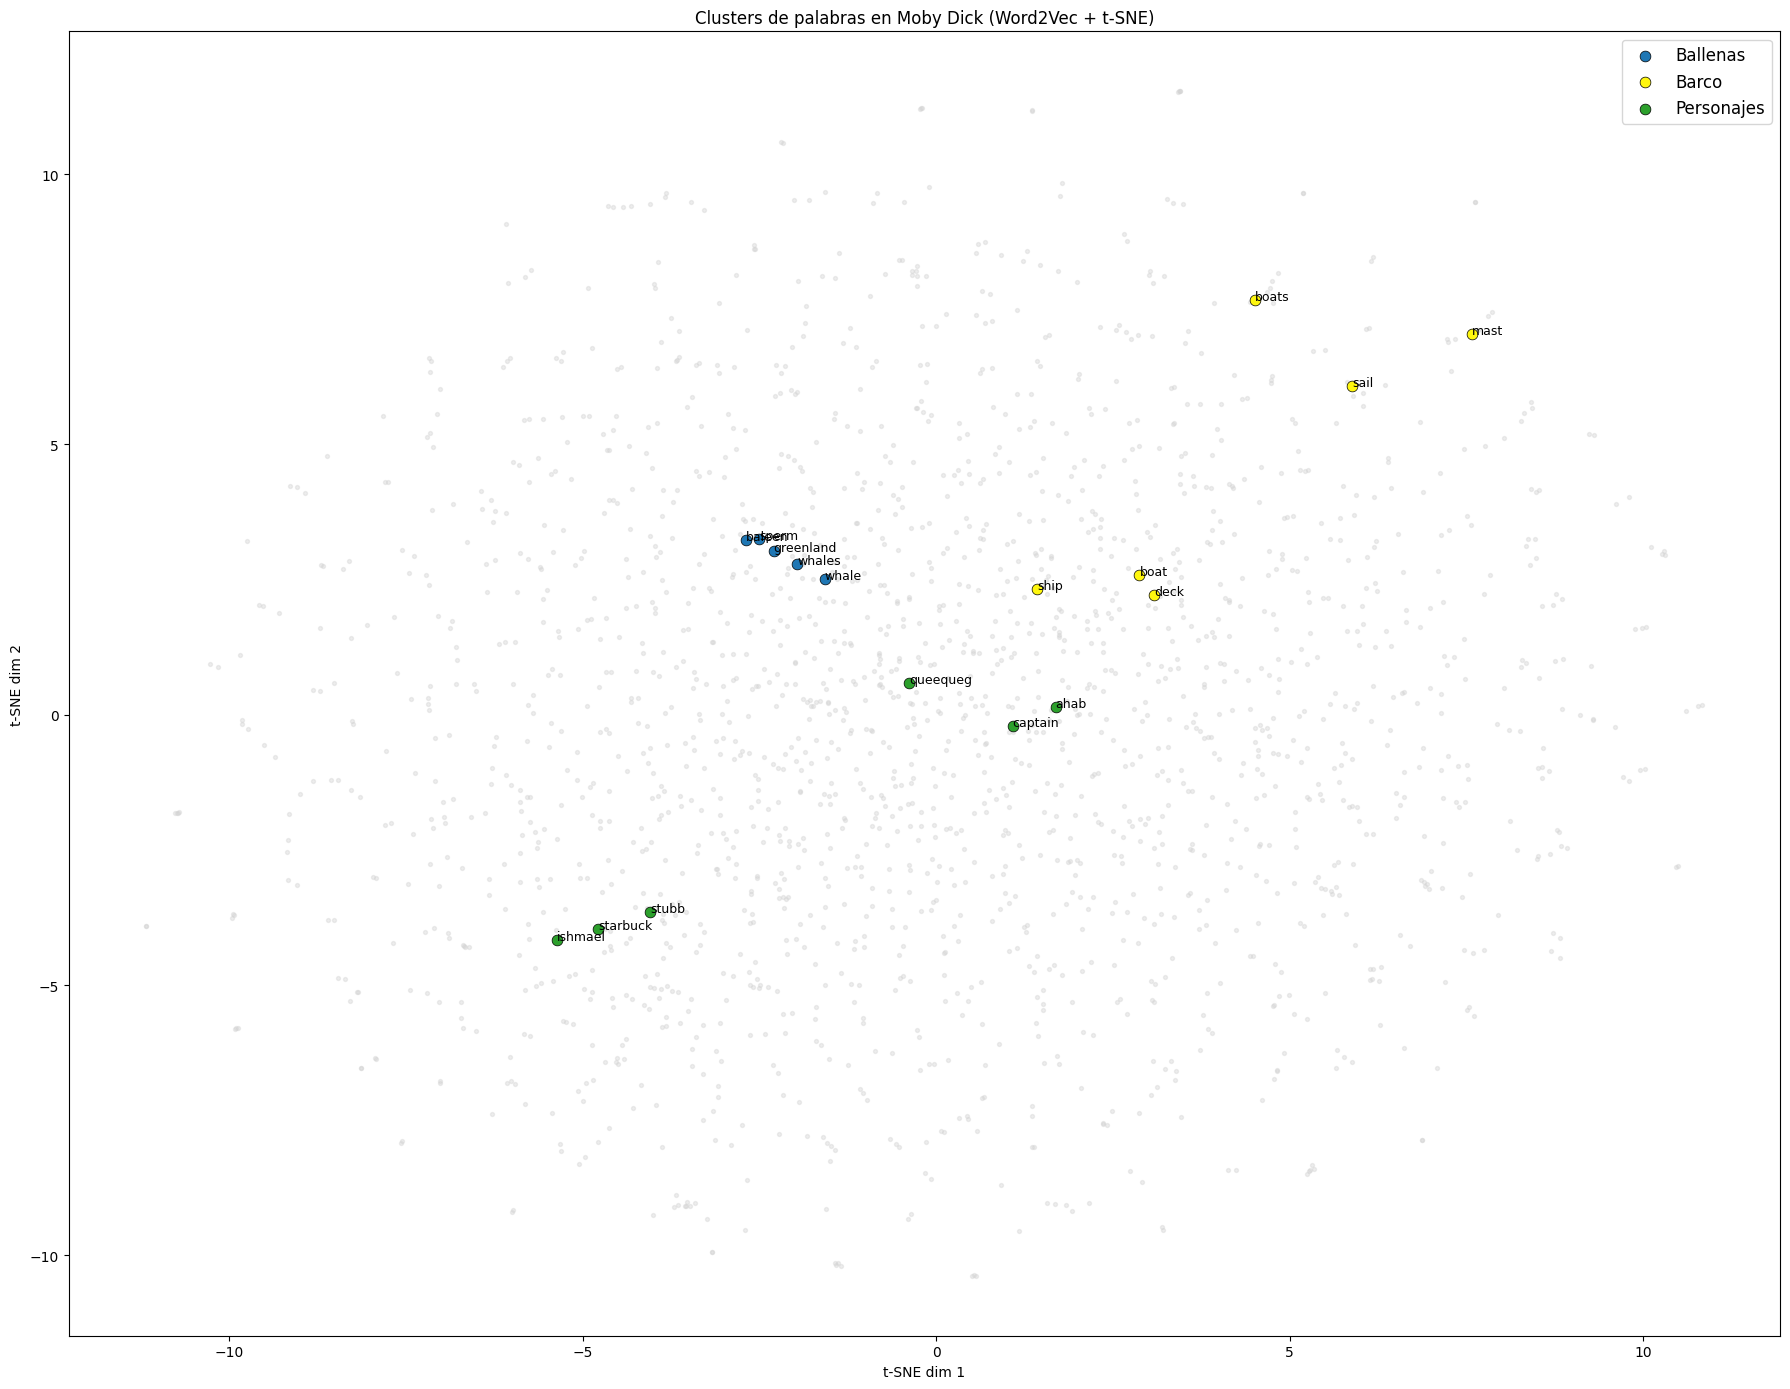

In [50]:
# Grupos de interes
word_groups = {
    "Ballenas": ["whale", "whales", "sperm", "greenland", "baleen"],
    "Barco": ["boat", "boats", "ship", "sail", "deck", "mast"],
    "Personajes": ["ishmael", "ahab", "captain", "queequeg", "starbuck", "stubb"],
}

# Diccionario word->group para las palabras que existan en el vocabulario
WORD_COUNT = 2015
word_to_group = {}
for group_name, words in word_groups.items():
    for w in words:
        if w in w2v_model.wv:
            word_to_group[w] = group_name

# Colores por grupo
colors = ["#1f77b4", "#fff70e", "#2ca02c", "#d62728"]
group_names = list(word_groups.keys())

plt.figure(figsize=(18, 14))
plt.scatter(vecs[:WORD_COUNT, 0], vecs[:WORD_COUNT, 1], s=8, c="lightgray", alpha=0.4)

for idx, group_name in enumerate(group_names):
    group_words = [w for w in word_groups[group_name] if w in w2v_model.wv]
    group_indices = [list(labels).index(w) for w in group_words if w in labels[:WORD_COUNT]]
    if group_indices:
        plt.scatter(
            vecs[group_indices, 0], vecs[group_indices, 1],
            s=60, c=colors[idx], label=group_name, edgecolors="black", linewidths=0.5
        )
        for i in group_indices:
            plt.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=9)

plt.legend(fontsize=12)
plt.title("Clusters de palabras en Moby Dick (Word2Vec + t-SNE)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

### Conclusiones

### Grupos de palabras identificados

1. **Ballenas**: Palabras como *whale*, *whales*, *sperm*, *greenland* y *baleen* tienden a agruparse en una región del espacio. Esto es coherente porque en la novela estos términos se refieren a ballenas y tipos de ellas.

2. **Barco**: Términos náuticos como *boat*, *boats*, *ship*, *sail*, *deck*, *mast* forman otro cluster reconocible, ya que representan a barcos y partes de los mismos.

3. **Personajes**: Nombres como *Ishmael*, *Ahab*, *Queequeg*, *Starbuck*, *Stubb*, *captain* aparecen próximos entre sí, ya que son todos personajes con roles dentro del barco y en la historia misma.

### Observaciones finales

- El modelo Word2Vec logra capturar relaciones semánticas coherentes a pesar de entrenarse en un único libro. Esto demuestra la capacidad del algoritmo para aprender de corpus relativamente pequeños.
- Las analogías y consultas de similitud reflejan el universo temático de la novela, mostrando que los embeddings están fuertemente relacionados al dominio del texto de entrenamiento.
- t-SNE permite visualizar estas relaciones de forma intuitiva, aunque hay que tener en cuenta que la proyección a 2D introduce distorsiones y los clusters visuales deben interpretarse con cautela.